In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import os
from autoemulate import AutoEmulate
from autoemulate.core.plotting import create_and_plot_slice
from lipb_surrogate import FestimProblem
import sys

/home/kaelyn/anaconda3/envs/tes-pav-env/lib/python3.12/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Reynolds number for LiPb at 0.5m/s is 543615.9929158624.
Schmidt number for LiPb is 144.8770408864817.
Density of LiPb at 603.15K is 9802.2938935kg/m3.
Initial turbulence kinetic energy for LiPb: 0.0009375000000000002 m2/s2
Initial turbulence dissipation rate for LiPb: 3.628235300029708e-05 m2/s3
Initial specific dissipation rate for LiPb: 0.43001307259611343 1/s


In [2]:
simulator = FestimProblem(
    parameters_range={
        "v_in": (0.01, 2.1),
        "c_in": (np.log10(1e15), np.log10(1e25)),
    },  # ranges for each variable
    output_names=["c_out"],
)

In [3]:
# load training data 
# TODO: make paths generic

X = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/trained_emulator_1/trained_inputs.csv", delimiter=",")
Y = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/trained_emulator_1/trained_outputs.csv", delimiter=",")

In [4]:
# train model 

ae = AutoEmulate(X, Y, log_level="info", models=["GaussianProcessRBF"])
emulator = [r for r in ae.results if r.model_name == "GaussianProcessRBF"][0]

print(f"Selected model: {emulator.model_name} with id: {emulator.id}")

ae.summarize()

INFO    2026-05-12 11:58:29,213 - autoemulate - Comparing ['GaussianProcessRBF']
INFO    2026-05-12 11:58:29,215 - autoemulate - Running Model: GaussianProcessRBF: 1/1 (attempt 1/3)
INFO    2026-05-12 11:58:51,789 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-05-12 11:58:51,790 - autoemulate - Using metric 'r2' to determine best result.
Selected model: GaussianProcessRBF with id: 0


,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
0,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.05, 'likelihood_cls': ...",-194.580902,593.62384,2.694580e+09,213605536.0,0.341725,2.227389,1.062446e+10,2.951745e+09


In [5]:
# save the model
path = "lipb_emulators/trained_emulator_1"
if not os.path.exists(path):
    os.makedirs(path)

emulator_filepath = ae.save(emulator, path, use_timestamp=True)
print("Model and metadata saved to: ", emulator_filepath)

INFO    2026-05-12 11:58:53,723 - autoemulate - GaussianProcessRBF_0_20260512_115853.joblib saved to lipb_emulators/trained_emulator_1/GaussianProcessRBF_0_20260512_115853


INFO    2026-05-12 11:58:53,735 - autoemulate - Metadata saved to lipb_emulators/trained_emulator_1/GaussianProcessRBF_0_20260512_115853_metadata.csv
Model and metadata saved to:  lipb_emulators/trained_emulator_1/GaussianProcessRBF_0_20260512_115853


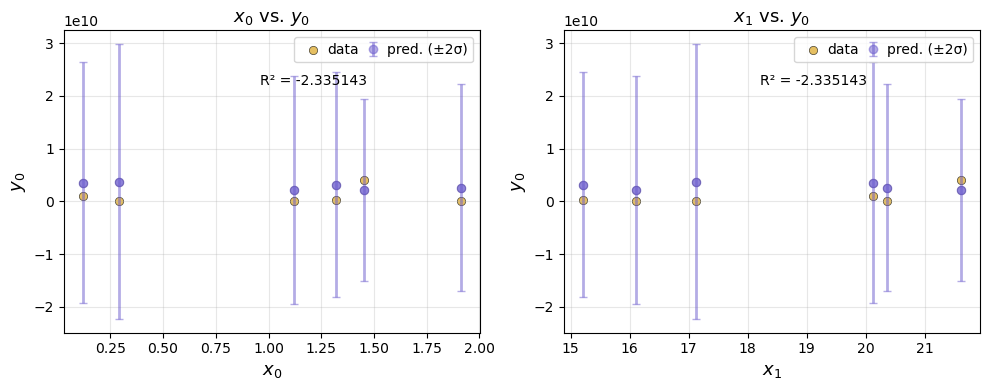

In [6]:
# plotting
ae.plot(emulator)

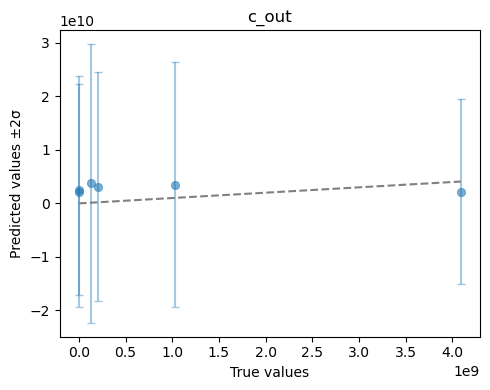

In [7]:
# plot predictions
ae.plot_preds(emulator, output_names=simulator.output_names)

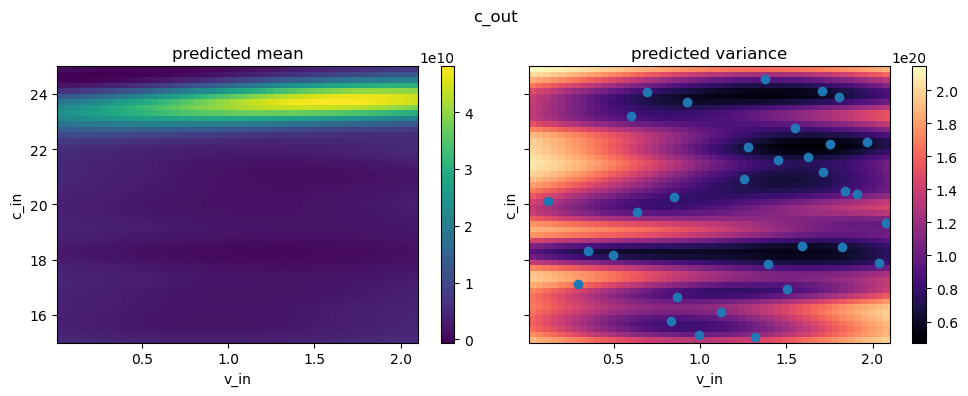

In [9]:
# plot mean and variance
for i in range(1):
    fig, axs = create_and_plot_slice(
        emulator.model,
        output_idx=i,
        parameters_range=simulator.parameters_range, 
        quantile=0.5,
        param_pair=(0, 1),
    )
    plt.scatter(X[:, 0], X[:, 1])
    plt.suptitle(f"{simulator.output_names[i]}")


WARNING 2026-05-12 12:54:27,388 - py.warnings - /tmp/ipykernel_2513428/3295314980.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_mean = np.array(y_mean)

WARNING 2026-05-12 12:54:27,389 - py.warnings - /tmp/ipykernel_2513428/3295314980.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_var = np.array(y_var).flatten()



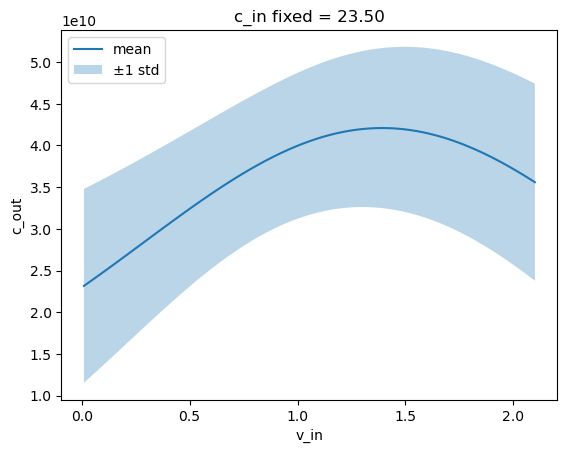

In [ ]:
# plot 1d slice fixed c_in
import torch

n_points = 100
v_in_range = simulator.parameters_range["v_in"]
fixed_c_in = 23.5 # in log scale, chosen from plot above 

v_in_vals = np.linspace(v_in_range[0], v_in_range[1], n_points)
v_in = np.column_stack([
    v_in_vals,
    np.full(n_points, fixed_c_in),
])
v_in = torch.from_numpy(v_in).float()

y_mean, y_var = emulator.model.predict_mean_and_variance(v_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0]  
y_std_1d = np.sqrt(y_var) 

# actual plotting 
ax.plot(v_in_vals, y_mean_1d, label='mean')
ax.fill_between(v_in_vals,
                y_mean_1d - y_std_1d,
                y_mean_1d + y_std_1d,
                alpha=0.3, label='±1 std')
ax.set_xlabel('v_in')
ax.set_ylabel(simulator.output_names[0])
ax.set_title(f'c_in fixed = {fixed_c_in:.2f}')
ax.legend()
plt.show()

WARNING 2026-05-12 12:52:22,093 - py.warnings - /tmp/ipykernel_2513428/317735048.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_mean = np.array(y_mean)

WARNING 2026-05-12 12:52:22,094 - py.warnings - /tmp/ipykernel_2513428/317735048.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_var = np.array(y_var).flatten()



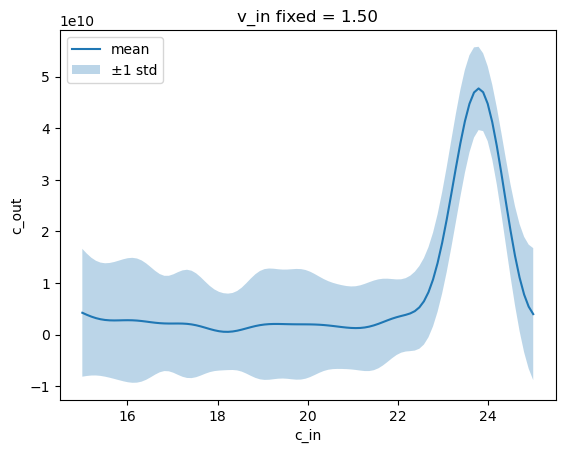

In [ ]:
# plot 1d slice for fixed v_in
import torch

n_points = 100
c_in_range = simulator.parameters_range["c_in"]
fixed_v_in = 1.5 

c_in_vals = np.linspace(c_in_range[0], c_in_range[1], n_points)
c_in = np.column_stack([
    np.full(n_points, fixed_v_in),
    c_in_vals,
])
c_in = torch.from_numpy(c_in).float()


y_mean, y_var = emulator.model.predict_mean_and_variance(c_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0]  
y_std_1d = np.sqrt(y_var) 

# actual plotting 
ax.plot(c_in_vals, y_mean_1d, label='mean')
ax.fill_between(c_in_vals,
                y_mean_1d - y_std_1d,
                y_mean_1d + y_std_1d,
                alpha=0.3, label='±1 std')
ax.set_xlabel('c_in')
ax.set_ylabel(simulator.output_names[0])
ax.set_title(f'v_in fixed = {fixed_v_in:.2f}')
ax.legend()
plt.show()

In [15]:
# sensitivity analysis 
from autoemulate.core.sensitivity_analysis import SensitivityAnalysis

problem = {
    'num_vars': simulator.in_dim,
    'names': simulator.param_names,
    'bounds': simulator.param_bounds,
    'output_names': simulator.output_names,
}
sa = SensitivityAnalysis(emulator.model, problem=problem)
sobol_df = sa.run("sobol")
sobol_df

,output,parameter,index,value,confidence
0,c_out,v_in,S1,0.012651,0.032801
1,c_out,c_in,S1,0.899734,0.116933
0,c_out,v_in,ST,0.115963,0.029555
1,c_out,c_in,ST,1.003789,0.087766
0,c_out,"[v_in, c_in]",S2,0.107599,0.078021


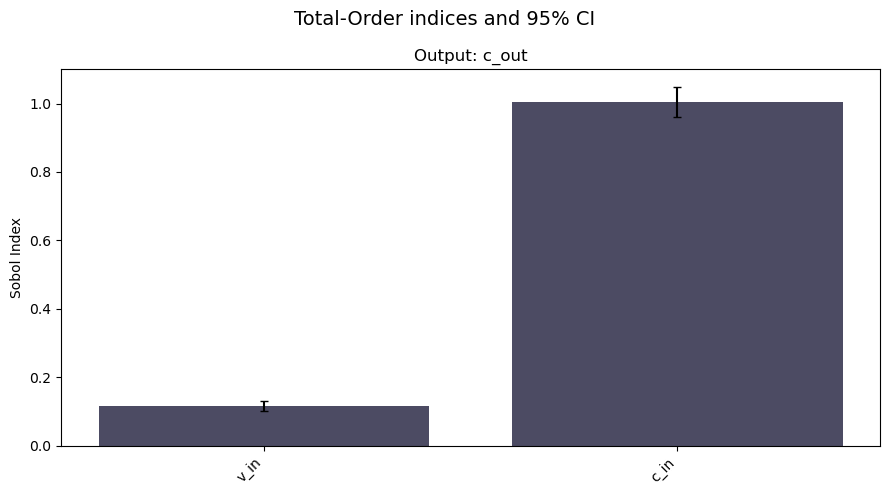

In [16]:
sa.plot_sobol(sobol_df, index="ST", figsize=(9, 5)) 

In [17]:
# morris sensitivity analysis
morris_df = sa.run("morris")
morris_df

,output,parameter,mu,mu_star,sigma,mu_star_conf
0,c_out,v_in,1.286586e+09,3.480544e+09,4.447947e+09,2.114452e+08
1,c_out,c_in,4.365026e+08,2.887840e+09,3.856985e+09,1.759985e+08


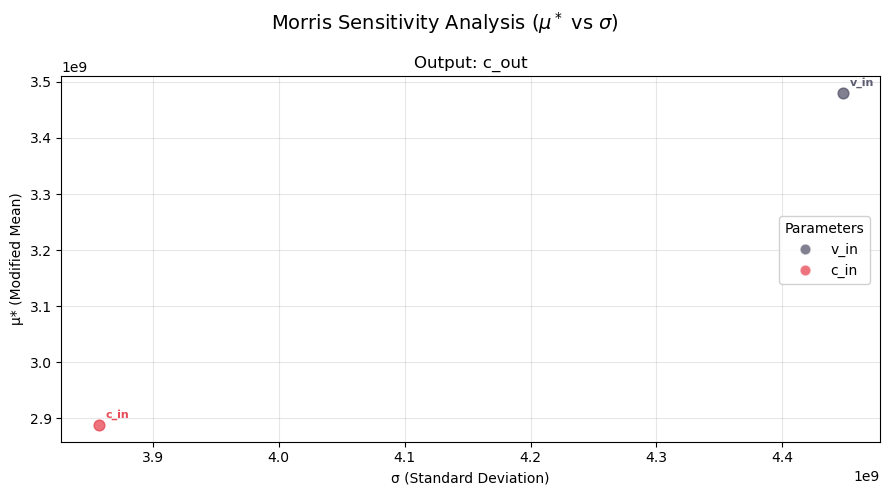

In [18]:
sa.plot_morris(morris_df, figsize=(9, 5))